In [46]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

In [47]:
# load dataset
df = pd.read_csv("../data/building_health_monitoring_dataset.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1000, 7)


,Timestamp,Accel_X (m/s^2),Accel_Y (m/s^2),Accel_Z (m/s^2),Strain (με),Temp (°C),Condition Label
0,2025-04-19 00:00:00,0.149014,0.419807,9.742482,61.843849,23.704760,0
1,2025-04-19 00:00:01,-0.041479,0.277390,9.795548,82.792300,24.953195,0
2,2025-04-19 00:00:02,0.194307,0.017889,9.730758,91.727889,25.027025,0
3,2025-04-19 00:00:03,0.456909,-0.194081,9.779204,137.753753,25.708946,0
4,2025-04-19 00:00:04,-0.070246,0.209467,9.620639,111.131062,22.949712,0


In [48]:
# inspect data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Timestamp        1000 non-null   object 
 1   Accel_X (m/s^2)  980 non-null    float64
 2   Accel_Y (m/s^2)  980 non-null    float64
 3   Accel_Z (m/s^2)  980 non-null    float64
 4   Strain (με)      980 non-null    float64
 5   Temp (°C)        980 non-null    float64
 6   Condition Label  1000 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 54.8+ KB


In [49]:
df = df.ffill()

In [50]:
df.isnull().sum()

Timestamp          0
Accel_X (m/s^2)    0
Accel_Y (m/s^2)    0
Accel_Z (m/s^2)    0
Strain (με)        0
Temp (°C)          0
Condition Label    0
dtype: int64

In [51]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Timestamp        1000 non-null   datetime64[ns]
 1   Accel_X (m/s^2)  1000 non-null   float64       
 2   Accel_Y (m/s^2)  1000 non-null   float64       
 3   Accel_Z (m/s^2)  1000 non-null   float64       
 4   Strain (με)      1000 non-null   float64       
 5   Temp (°C)        1000 non-null   float64       
 6   Condition Label  1000 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 54.8 KB


In [52]:
df.describe()

,Timestamp,Accel_X (m/s^2),Accel_Y (m/s^2),Accel_Z (m/s^2),Strain (με),Temp (°C),Condition Label
count,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2025-04-19 00:08:19.500000,0.098143,0.020239,9.812386,112.033122,25.025416,0.409000
min,2025-04-19 00:00:00,-0.795291,-0.882117,9.508049,41.860236,20.244361,0.000000
25%,2025-04-19 00:04:09.750000128,-0.151319,-0.180919,9.747016,92.125805,24.036035,0.000000
50%,2025-04-19 00:08:19.500000,0.077325,0.016289,9.811067,109.094129,25.059944,0.000000
75%,2025-04-19 00:12:29.249999872,0.306407,0.218665,9.877443,128.964223,26.045197,1.000000
max,2025-04-19 00:16:39,1.337972,0.941325,10.202624,224.861859,29.838898,2.000000
std,NaN,0.341001,0.296650,0.098146,28.860570,1.520429,0.684242


In [53]:
# df["Accel_X (m/s^2)"].fillna(df["Accel_X (m/s^2)"].mean(), inplace=True)
# df["Accel_Y (m/s^2)"].fillna(df["Accel_Y (m/s^2)"].mean(), inplace=True)
# df["Accel_Z (m/s^2)"].fillna(df["Accel_Z (m/s^2)"].mean(), inplace=True)
# df["Strain (με)"].fillna(df["Strain (με)"].mean(), inplace=True)
# df["Temp (°C)"].fillna(df["Temp (°C)"].mean(), inplace=True)

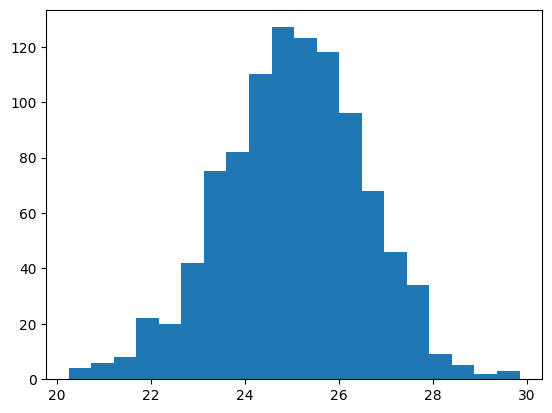

In [55]:
plt.hist(df["Temp (°C)"], bins=20)
plt.show()

In [56]:
# chech for outliers
num_cols = df[["Accel_X (m/s^2)", "Accel_Y (m/s^2)", "Accel_Z (m/s^2)", "Strain (με)", "Temp (°C)"]]
q1 = num_cols.quantile(0.25)
q3 = num_cols.quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = ((num_cols < lower_bound) | (num_cols > upper_bound))
outliers.sum()

Accel_X (m/s^2)    13
Accel_Y (m/s^2)     7
Accel_Z (m/s^2)    10
Strain (με)        16
Temp (°C)          12
dtype: int64

In [57]:
map = {
    0: "Healthy",
    1: "Minor Damage",
    2: "Severe Damage"
}
df["Label"] = df["Condition Label"].replace(map)
df.head()

,Timestamp,Accel_X (m/s^2),Accel_Y (m/s^2),Accel_Z (m/s^2),Strain (με),Temp (°C),Condition Label,Label
0,2025-04-19 00:00:00,0.149014,0.419807,9.742482,61.843849,23.704760,0,Healthy
1,2025-04-19 00:00:01,-0.041479,0.277390,9.795548,82.792300,24.953195,0,Healthy
2,2025-04-19 00:00:02,0.194307,0.017889,9.730758,91.727889,25.027025,0,Healthy
3,2025-04-19 00:00:03,0.456909,-0.194081,9.779204,137.753753,25.708946,0,Healthy
4,2025-04-19 00:00:04,-0.070246,0.209467,9.620639,111.131062,22.949712,0,Healthy


In [58]:
class_distribution = df["Label"].value_counts(normalize=True) * 100
class_distribution

Label
Healthy          70.4
Minor Damage     18.3
Severe Damage    11.3
Name: proportion, dtype: float64

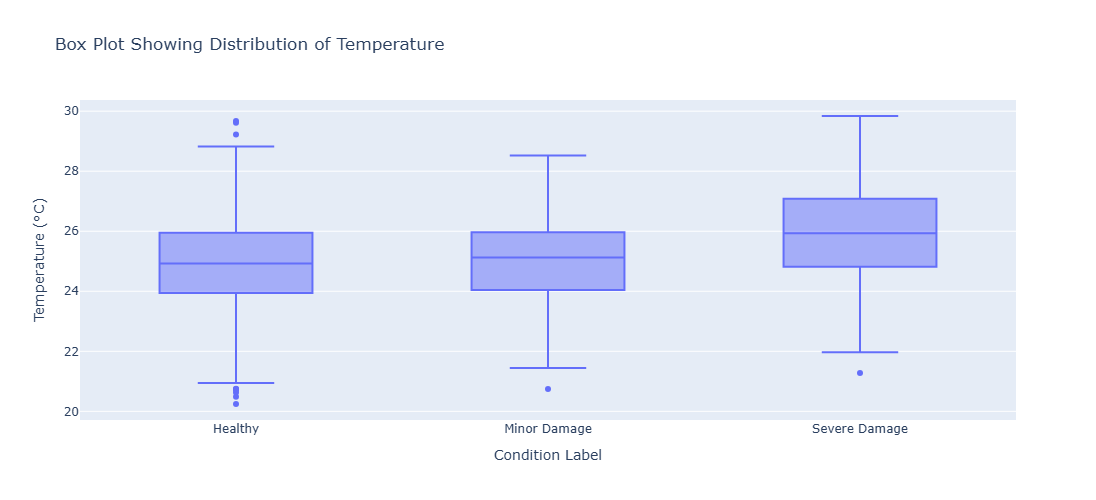

In [59]:
fig = px.box(
    df,
    y="Temp (°C)",
    x="Label",
    width=800,
    height=500,
    title="Box Plot Showing Distribution of Temperature"
)
fig.update_layout(xaxis_title="Condition Label", yaxis_title="Temperature (°C)")
fig.show()

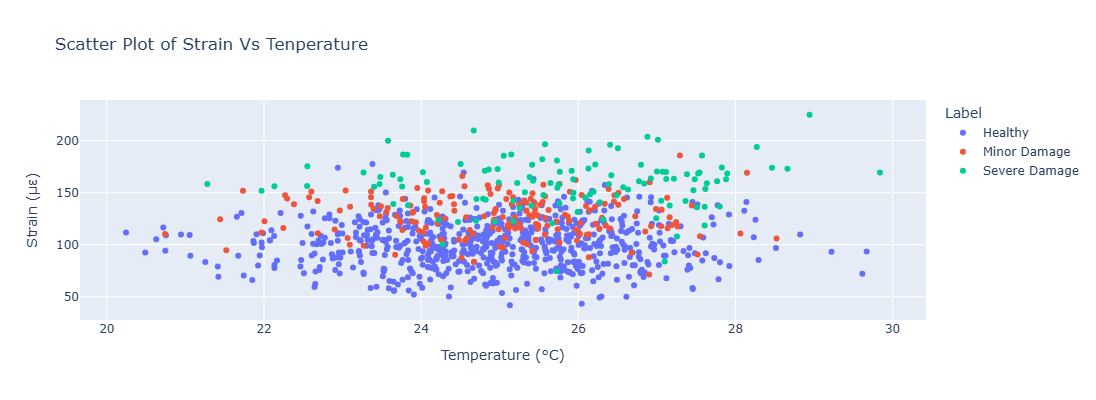

In [60]:
fig = px.scatter(
    df,
    y="Strain (με)",
    x="Temp (°C)",
    color="Label",
    width=600,
    height=400,
    title="Scatter Plot of Strain Vs Tenperature"
)
fig.update_layout(xaxis_title="Temperature (°C)", yaxis_title="Strain (με)")
fig.show()

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Timestamp        1000 non-null   datetime64[ns]
 1   Accel_X (m/s^2)  1000 non-null   float64       
 2   Accel_Y (m/s^2)  1000 non-null   float64       
 3   Accel_Z (m/s^2)  1000 non-null   float64       
 4   Strain (με)      1000 non-null   float64       
 5   Temp (°C)        1000 non-null   float64       
 6   Condition Label  1000 non-null   int64         
 7   Label            1000 non-null   object        
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 62.6+ KB


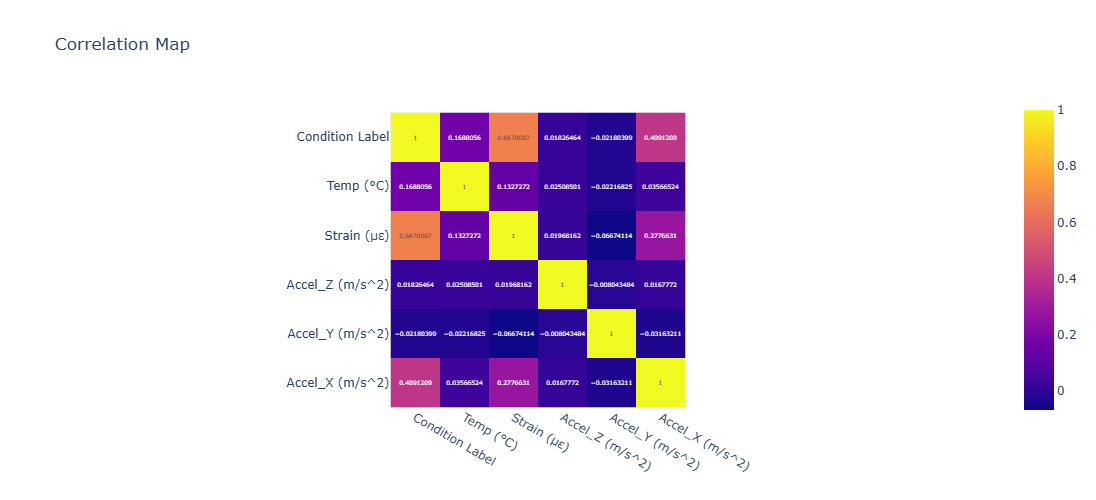

In [62]:
corr = df[["Condition Label","Temp (°C)", "Strain (με)", "Accel_Z (m/s^2)", "Accel_Y (m/s^2)", "Accel_X (m/s^2)"]].corr()
fig = px.imshow(
    corr,
    text_auto=True,
    width=500,
    height=500,
    title="Correlation Map"
)
fig.show()

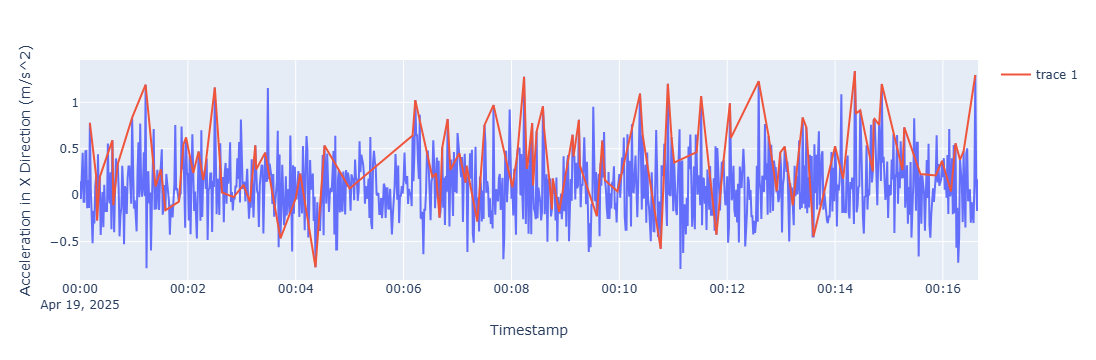

In [63]:
fig = px.line(
    df,
    x="Timestamp",
    y="Accel_X (m/s^2)"
)
severe = df[df["Label"] == "Severe Damage"]
fig.add_scatter(
    x=severe["Timestamp"],
    y=severe["Accel_X (m/s^2)"]
)
fig.update_layout(xaxis_title="Timestamp", yaxis_title="Acceleration in X Direction (m/s^2)")
fig.show()

In [64]:
feat = [
    "Timestamp",
    "Accel_X (m/s^2)",
    "Strain (με)",
    "Temp (°C)",
    "Condition Label"
]
df_model = df[feat].set_index("Timestamp")
df_model.head()
print("Data shape:", df_model.shape)

Data shape: (1000, 4)


In [65]:
df_model.to_csv("../data/building_health_monitoring_model_dataset.csv")